Notebook realizado por Juan David Sánchez. Contacto: juan.sanchez34@udea.edu.co

# **Sesión 5 - Similitud química**

El dataset 1 contiene información acerca de las moléculas con bioactividad reportada frente al target Proteína Precursora Amiloidea (APP), el cual fue obtenido a partir de la base de datos PubChem.

El dataset 2 y el dataset 3 contienen información referente moléculas con bioactividad hacia los targets GPR40 y G9a. Son bases de datos curada por DIFACQUIM.

In [ ]:
# Importing necessary libraries

import os
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import urllib.request
import time
import pip
! pip install rdkit
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, AllChem, MACCSkeys, rdFingerprintGenerator

📗📘📙📌 **Importe y homogenización de las bases de datos** 📌📙📘📗

In [3]:
# Importing databases
APP_df = pd.read_csv("https://raw.githubusercontent.com/Sanchez-Juan/Course__Chemoinformatics-applied-to-drug-design/refs/heads/main/app_pubchem.csv") # APP dataset from PubChem
GPR40_df = pd.read_csv("https://raw.githubusercontent.com/DIFACQUIM/Cursos/main/Datasets/08_Similitud_GPR40.csv") # GPR40 dataset
G9a_df = pd.read_csv("https://raw.githubusercontent.com/DIFACQUIM/Cursos/refs/heads/main/Datasets/08_Similitud_compounds_g9a.csv") # G9a dataset

print("🔶 Las columnas que contiene cada base de datos son:")
print(f"- APP dataset: {APP_df.columns.tolist()}")
print(f"- GPR40 dataset: {GPR40_df.columns.tolist()}")
print(f"- G9a dataset: {G9a_df.columns.tolist()}")
print(f"\n🔷 El número de compuestos en cada base de datos es: APP-PubChem: {APP_df.shape[0]}, GPR40: {GPR40_df.shape[0]}, G9a: {G9a_df.shape[0]}")

🔶 Las columnas que contiene cada base de datos son:
- APP dataset: ['Molecule_id', 'Activity Value [nM]', 'SMILES', 'Molecules', 'MW', 'HBA', 'HBD', 'logP', 'TPSA', 'CSP3', 'NumRings', 'HetAtoms', 'RotBonds', 'Murcko_SMILES', 'Scaffold', 'Source']
- GPR40 dataset: ['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type'

In [4]:
# Renaming and selecting relevant columns in order to concatenate the databases

APP_df = APP_df[["Source", "Molecule_id", "Activity Value [nM]", "SMILES"]]
APP_df["Source"] = APP_df["Source"].str.replace("PubChem", "APP-PubChem")
APP_df = APP_df.rename(columns={"Source": "Dataset"})

GPR40_df["Dataset"] = "GPR40-ChEMBL"
GPR40_df = GPR40_df[["Dataset", "Molecule ChEMBL ID", "Standard Value", "Smiles"]]
GPR40_df = GPR40_df.rename(columns={"Molecule ChEMBL ID": "Molecule_id", "Standard Value": "Activity Value [nM]", "Smiles": "SMILES"})

G9a_df["Dataset"] = "G9a-ChEMBL"
G9a_df = G9a_df[["Dataset", "molecule_chembl_id", "IC50", "smiles"]]
G9a_df = G9a_df.rename(columns={"molecule_chembl_id": "Molecule_id", "IC50": "Activity Value [nM]", "smiles": "SMILES"})

# Concatenating the three databases into a single dataframe and creating a new column with the molecular objects
data = pd.concat([APP_df, GPR40_df, G9a_df], ignore_index=True)
data["Mol"] = data["SMILES"].apply(lambda x: Chem.MolFromSmiles(x))
print(f"🔷 El número total de compuestos en el dataframe combinado es: {data.shape[0]}")
data.sample(3)

🔷 El número total de compuestos en el dataframe combinado es: 2018


,Dataset,Molecule_id,Activity Value [nM],SMILES,Mol
536,APP-PubChem,164614160,1320.0,CCN(CCCOC1=CC(=C(C=C1)C(=O)/C=C/C2=CC=C(C=C2)N...,<rdkit.Chem.rdchem.Mol object at 0x00000210EA3...
323,APP-PubChem,122191852,15000.0,C1=CC=C2C(=C1)C3=CC(=C(C(=C3N2)O)C(=O)O)O,<rdkit.Chem.rdchem.Mol object at 0x00000210EA3...
1875,G9a-ChEMBL,CHEMBL4856508,1650,COc1cc2c(NCc3ccc([C@H]4CC[C@H](C(=O)NO)CC4)cc3...,<rdkit.Chem.rdchem.Mol object at 0x00000210EB5...


📗📘📙📌 **Representación molecular con fingerprints** 📌📙📘📗

In [5]:
# Creating a function to calculate the fingerprints (MACCSkeys and ECFP4) for each molecule in the dataframe
def calculate_fp(df, column_name):
    """
    Calculates multiple molecular fingerprints:
    - ECFP4 (Morgan fingerprint)
    - MACCS keys
    and adds them as new columns to the DataFrame.
    """
    start_time = time.time()

    # Fingerprint generators
    ecfp4_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    fingerprints = {"ECFP4": [], "MACCS": []}
    
    for mol in df[column_name]:
        if mol is None:
            for key in fingerprints:
                fingerprints[key].append(None)
            continue

        # -------- ECFP4 --------
        fingerprints["ECFP4"].append(ecfp4_gen.GetFingerprint(mol))

        # -------- MACCS --------
        fingerprints["MACCS"].append(MACCSkeys.GenMACCSKeys(mol))

    # Add fingerprints to the dataframe
    for key in fingerprints:
        df[key] = fingerprints[key]

    elapsed = time.time() - start_time
    print(f"⌛ Tiempo de ejecución: {elapsed:.2f} segundos")

    return df.sample(3)

In [6]:
calculate_fp(data, "Mol")

⌛ Tiempo de ejecución: 3.02 segundos


,Dataset,Molecule_id,Activity Value [nM],SMILES,Mol,ECFP4,MACCS
513,APP-PubChem,155517170,17890.0,C1CN(CCN1CC(=O)NC2=C3C=CC=NC3=NN2)CC(=O)NC4=C5...,<rdkit.Chem.rdchem.Mol object at 0x00000210EA3...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1905,G9a-ChEMBL,CHEMBL4213346,3080,COc1cc2c(NC3CC4(CCN(C)CC4)C3)cc(-c3ccc(C)o3)nc...,<rdkit.Chem.rdchem.Mol object at 0x00000210EB5...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
1026,APP-PubChem,168284429,6696.0,CC1=CC2=C(C=C1)N=C3CCCCC3=C2N4CCCCC4,<rdkit.Chem.rdchem.Mol object at 0x00000210EB5...,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


📗📘📙📌 **Análisis de similitud molecular usando el coeficiente de Tanimoto** 📌📙📘📗

In [ ]:
# Necessary libraries: rdkit for cheminformatics operations (Chem, DataStructs, AllChem) and numpy for array manipulations

# Metric dictionary
similarity_metrics = {
    'tanimoto': DataStructs.TanimotoSimilarity,
    'dice': DataStructs.DiceSimilarity,
    'cosine': DataStructs.CosineSimilarity,
    'sokal': DataStructs.SokalSimilarity,
    'tversky': lambda fp1, fp2: DataStructs.TverskySimilarity(fp1, fp2, 0.5, 0.5)
}

def calculate_similarity(smi1, smi2, radius=2, n_bits=2048, method='tanimoto'):
    """
    Calculates the similarity between two molecules with error handling and optimized metrics.
    """
    # Validation and conversion from SMILES to Mol
    mol1 = Chem.MolFromSmiles(smi1)
    mol2 = Chem.MolFromSmiles(smi2)

    if mol1 is None or mol2 is None:
        print("Error: SMILES invalido detectado.")
        return None

    # Fingerprint Generation (Using GetMorganGenerator is the modern approach in RDKit)
    fpgen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp1 = fpgen.GetFingerprint(mol1)
    fp2 = fpgen.GetFingerprint(mol2)

    # Similarity Calculation
    method = method.lower()

    if method in similarity_metrics:
        similarity = similarity_metrics[method](fp1, fp2)
    elif method == 'euclidean':
        # For spatial distances, we use bit vectors
        arr1 = np.zeros((n_bits,), dtype=np.int8)
        arr2 = np.zeros((n_bits,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp1, arr1)
        DataStructs.ConvertToNumpyArray(fp2, arr2)
        
        # Euclidean similarity is usually expressed as 1 / (1 + distance)
        dist = np.linalg.norm(arr1 - arr2)
        similarity = 1.0 / (1.0 + dist)
    else:
        valid_options = list(similarity_metrics.keys()) + ['euclidean']
        raise ValueError(f"Método '{method}' no reconocido. Opciones: {valid_options}")

    return round(similarity, 4)

In [ ]:
# Necesary libraries: time for measuring execution time, numpy for array manipulations, pandas for data handling, and rdkit for cheminformatics operations (Chem, DataStructs, AllChem).

# Take a sample of 100 molecules for testing
df_sample = data.sample(n=100, random_state=1)

start_time = time.time()

# Extract columns to lists
smiles_list = df_sample['SMILES'].tolist()
chembl_ids = df_sample['Molecule_id'].tolist()

fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
fps = []
valid_names = []

# Generate Mols and Fingerprints linearly (O(N))
for smiles, chembl_id in zip(smiles_list, chembl_ids):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fps.append(fpgen.GetFingerprint(mol))
        valid_names.append(chembl_id)

n_valid = len(fps)
# Numpy array for the similarity matrix
sim_matrix = np.zeros((n_valid, n_valid))

# Calculate similarity matrix
for i in range(n_valid):
    # DataStructs.BulkTanimotoSimilarity compares one FP against a list of FPs
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i:])
    sim_matrix[i, i:] = sims # Fill row
    sim_matrix[i:, i] = sims # Fill column to keep the matrix symmetrical

# Construct final correlation DataFrame
hmap = pd.DataFrame(sim_matrix, index=valid_names, columns=valid_names)
elapsed = time.time() - start_time

print(f"🔶 Se procesaron {n_valid} moléculas\n")
print(f"⌛ Tiempo de ejecución: {elapsed:.2f} segundos")

🔶 Se procesaron 100 moléculas

⌛ Tiempo de ejecución: 0.04 segundos


In [17]:
hmap

,24782385,72545287,57385882,153606621,9894522,68556085,CHEMBL4290900,57386668,24785955,CHEMBL2441079,...,54579969,53239460,CHEMBL4164497,164629153,CHEMBL4213346,CHEMBL484771,CHEMBL1214066,CHEMBL4552592,172469150,CHEMBL4212905
24782385,1.000000,0.067568,0.070423,0.120482,0.159420,0.313725,0.132530,0.068493,0.473684,0.121951,...,0.079365,0.203390,0.137500,0.246575,0.134146,0.095890,0.125000,0.104651,0.081081,0.134146
72545287,0.067568,1.000000,0.122222,0.092593,0.105263,0.135802,0.122642,0.072917,0.094595,0.103774,...,0.081395,0.103448,0.126214,0.148515,0.072727,0.141304,0.084906,0.100917,0.179775,0.092593
57385882,0.070423,0.122222,1.000000,0.116505,0.108696,0.059524,0.084112,0.492537,0.068493,0.075472,...,0.125000,0.081395,0.097087,0.056075,0.127451,0.073684,0.066667,0.054054,0.051546,0.095238
153606621,0.120482,0.092593,0.116505,1.000000,0.101852,0.115789,0.176991,0.114286,0.104651,0.190909,...,0.091837,0.100000,0.192661,0.160714,0.178571,0.101852,0.183486,0.165217,0.053097,0.168142
9894522,0.159420,0.105263,0.108696,0.101852,1.000000,0.256757,0.090909,0.094737,0.138889,0.082569,...,0.119048,0.141176,0.114286,0.147059,0.122642,0.127660,0.084112,0.100000,0.081633,0.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL484771,0.095890,0.141304,0.073684,0.101852,0.127660,0.162500,0.132075,0.083333,0.093333,0.102804,...,0.056180,0.141176,0.135922,0.181818,0.122642,1.000000,0.094340,0.110092,0.152174,0.112150
CHEMBL1214066,0.125000,0.084906,0.066667,0.183486,0.084112,0.131868,0.666667,0.075472,0.135802,0.505882,...,0.094737,0.091837,0.411111,0.221154,0.343750,0.094340,1.000000,0.310000,0.054545,0.343750
CHEMBL4552592,0.104651,0.100917,0.054054,0.165217,0.100000,0.136842,0.285714,0.081818,0.102273,0.400000,...,0.079208,0.108911,0.269231,0.157895,0.218182,0.110092,0.310000,1.000000,0.080357,0.207207
172469150,0.081081,0.179775,0.051546,0.053097,0.081633,0.120482,0.111111,0.050505,0.078947,0.063063,...,0.068182,0.102273,0.093458,0.147059,0.072072,0.152174,0.054545,0.080357,1.000000,0.072072


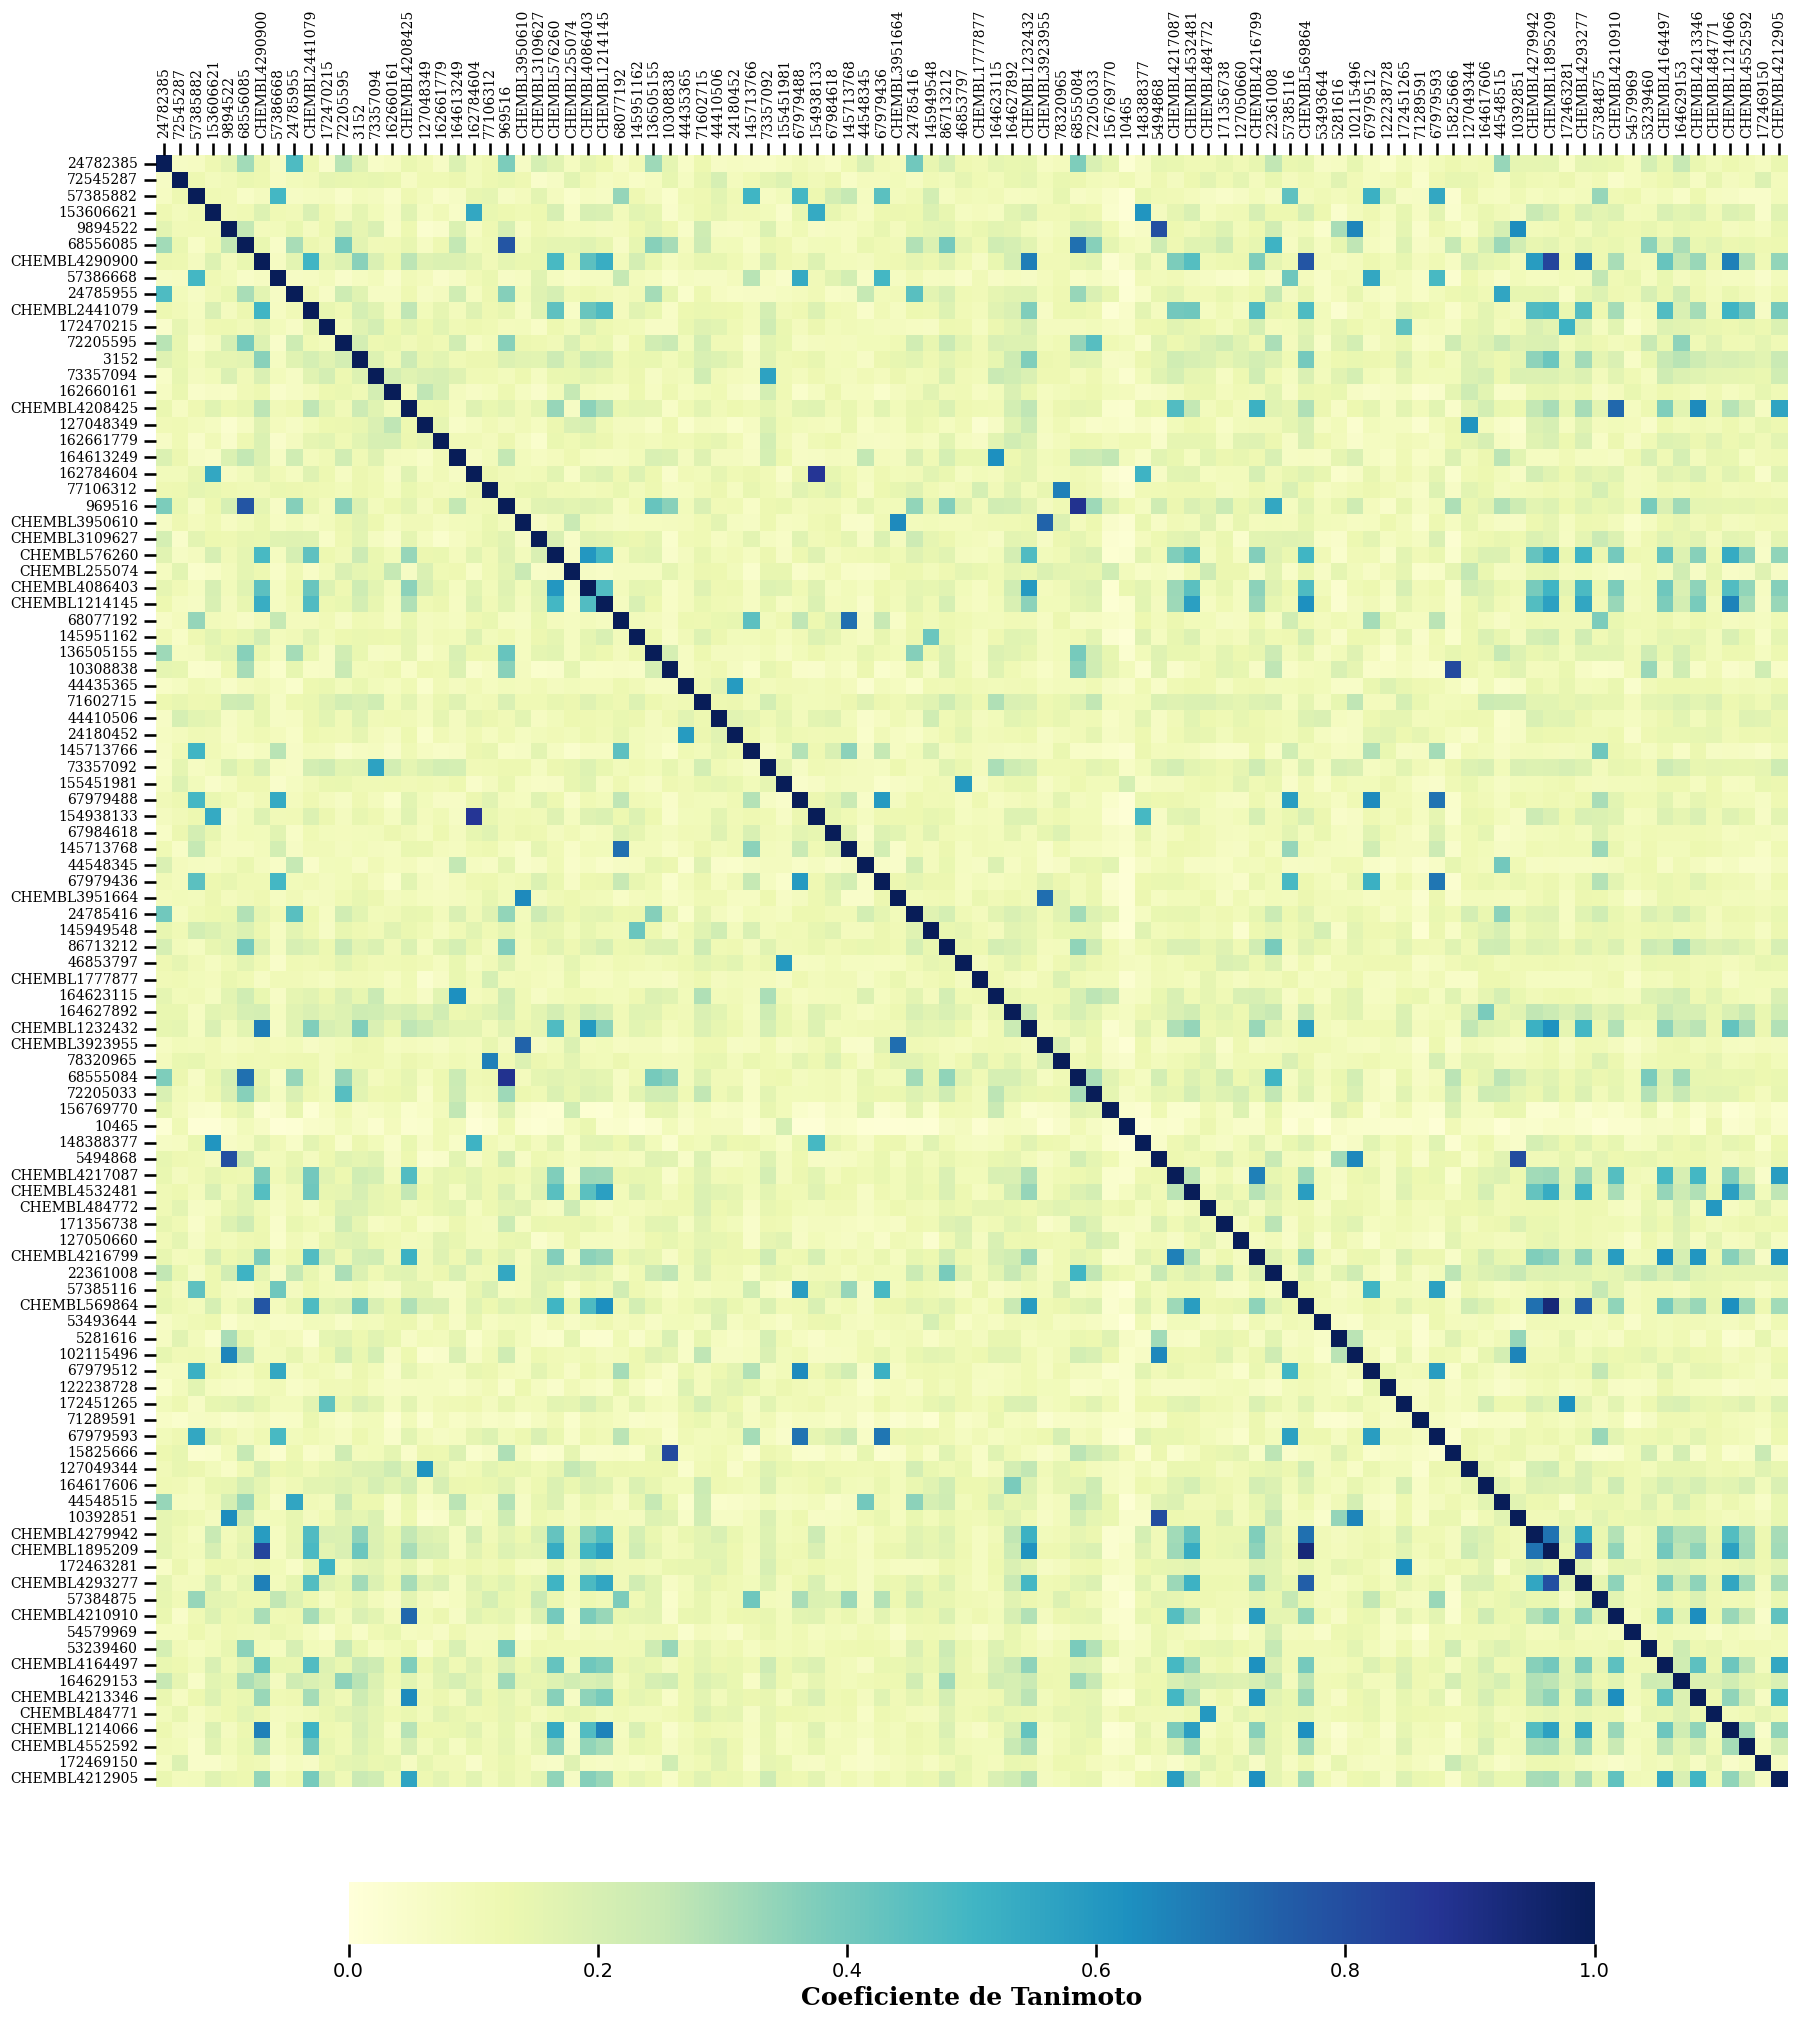

In [ ]:
# Necesary libraries: seaborn and matplotlib for visualization of the heatmap

# Using a custom color palette
palette = sns.blend_palette(['black', 'blue', 'orange'], as_cmap=True)

# Scales fonts proportionally
sns.set_context("talk", font_scale=1.5) 

# 'layout=constrained' prevents overlapping better than tight_layout
fig, ax = plt.subplots(figsize=(25, 20), layout='constrained') 

# Simplified Heatmap # cmap=palette, cmap='magma', cmap='mako', cmap='YlGnBu'
sns.heatmap(hmap, square=True, cmap='YlGnBu', vmin=0, vmax=1, ax=ax, xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.05})

# Move X-axis labels to the top
ax.xaxis.tick_top() 

plt.xticks(rotation=90, fontsize = 10, fontfamily='serif')
plt.yticks(rotation=0, fontsize = 10, fontfamily='serif')

# Format the colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Coeficiente de Tanimoto', size=18, weight='bold', fontfamily='serif')

# plt.savefig('tanimoto_coefficient.png', dpi=300, bbox_inches='tight')
plt.show()

📗📘📙📌 **X** 📌📙📘📗